# Phase 2 — backtest report

LightGBM (global, quantile, direct per horizon) vs naive / seasonal-naive / 7-day MA on the 19
series in `config/series.yaml`. Reads the latest `reports/backtest_<date>/` written by
`python -m cropcast.pipeline --steps features,train,backtest` and the matching parquet snapshot.

Official backtest: 5 walk-forward folds × 14-day windows ending at the latest date (all after the
Agmarknet 2.0 portal switch). Sections 5–6 add a **diagnostic** 52-fold (≈ 2-year) h=7 backtest,
p50 only, to look at seasonality and the portal switch — it is not the reported metric.

In [1]:
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from cropcast.config import settings
from cropcast.features.build import build_features
from cropcast.features.series import load_series
from cropcast.models.backtest import comparison_table, metrics_table, run_backtest

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200, "display.max_columns", 30, "display.max_rows", 80)

# Fixed categorical order: one hue per model (validated palette), never re-ordered.
MODEL_COLORS = {"lgbm": "#2a78d6", "naive": "#eb6834", "seasonal_naive": "#1baf7a",
                "moving_average": "#eda100"}
INK, MUTED, GRID = "#0b0b0b", "#898781", "#e6e5e0"
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb", "axes.edgecolor": MUTED,
    "axes.labelcolor": INK, "xtick.color": MUTED, "ytick.color": MUTED, "axes.grid": True,
    "grid.color": GRID, "grid.linewidth": 0.6, "axes.spines.top": False,
    "axes.spines.right": False, "axes.axisbelow": True, "lines.linewidth": 1.2,
    "font.size": 9, "axes.titlesize": 10, "axes.titleweight": "bold", "legend.frameon": False,
})

report = sorted((settings.reports_dir).glob("backtest_*"))[-1]
last = pd.Timestamp(report.name.removeprefix("backtest_"))
preds = pd.read_parquet(report / "predictions.parquet")
snap_path = sorted((settings.data_dir / "snapshots").glob("prices_clean_*.parquet"))[-1]
prices = pd.read_parquet(snap_path)
weather = pd.read_parquet(str(snap_path).replace("prices_clean_", "weather_"))
print(f"report: {report.name} | data to {last.date()} | {len(preds):,} prediction rows | "
      f"snapshot {snap_path.name}")

report: backtest_2026-10-06 | data to 2026-10-06 | 11,812 prediction rows | snapshot prices_clean_2026-10-07.parquet


## 1. Headline: LGBM vs baselines by horizon (all 19 series pooled)

In [2]:
by_h = comparison_table(preds, ["horizon"])
by_h.round(3)

,horizon,n_lgbm,mape_lgbm,mape_naive,mape_seasonal_naive,mape_moving_average,smape_lgbm,smape_naive,smape_seasonal_naive,mase_lgbm,mase_naive,mase_seasonal_naive,coverage_80_lgbm,lgbm_beats_naive
0,1,988.0,2.587,2.580,4.673,3.214,2.558,2.570,4.728,1.154,1.155,2.114,82.692,False
1,7,983.0,4.774,4.714,4.714,5.157,4.840,4.779,4.779,2.178,2.149,2.149,80.061,False
2,14,982.0,7.075,6.972,6.972,7.379,7.266,7.141,7.141,3.420,3.209,3.209,76.782,False


## 2. Per crop × horizon

,commodity,horizon,n_lgbm,mape_lgbm,mape_naive,mape_seasonal_naive,mape_moving_average,mase_lgbm,mase_naive,coverage_80_lgbm,lgbm_beats_naive
0,banana,1,444.0,3.15,3.10,6.94,4.46,0.96,0.95,81.31,False
1,banana,7,438.0,7.30,7.14,7.14,8.08,2.37,2.33,76.94,False
2,banana,14,437.0,10.78,10.88,10.88,11.67,3.44,3.47,74.83,True
3,coconut,1,168.0,1.70,1.69,3.22,2.26,1.38,1.38,80.95,False
4,coconut,7,168.0,3.34,3.27,3.27,3.74,3.13,3.05,79.76,False
5,coconut,14,168.0,6.11,5.25,5.25,5.77,6.26,5.35,62.50,False
6,pepper,1,144.0,0.12,0.11,0.26,0.17,0.28,0.26,94.44,False
7,pepper,7,144.0,0.28,0.26,0.26,0.29,0.66,0.60,86.11,False
8,pepper,14,144.0,0.46,0.38,0.38,0.43,1.17,0.88,81.94,False
9,rubber,1,49.0,3.34,3.57,3.24,2.92,1.47,1.56,75.51,True


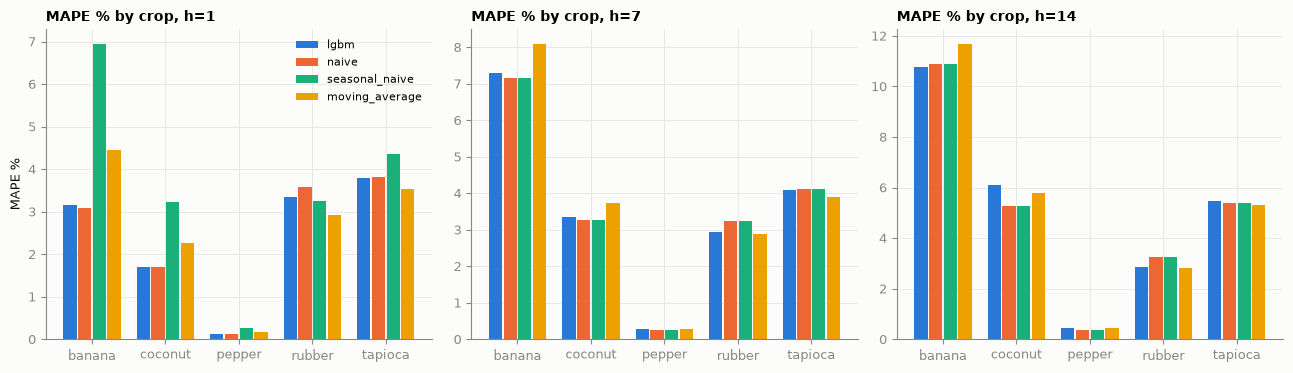

In [3]:
by_c = comparison_table(preds, ["commodity", "horizon"])
display(by_c[["commodity", "horizon", "n_lgbm", "mape_lgbm", "mape_naive", "mape_seasonal_naive",
              "mape_moving_average", "mase_lgbm", "mase_naive", "coverage_80_lgbm",
              "lgbm_beats_naive"]].round(2))

long = metrics_table(preds, ["commodity", "horizon"])
crops = sorted(long["commodity"].unique())
models = list(MODEL_COLORS)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharey=False)
for ax, h in zip(axes, (1, 7, 14)):
    sub = long[long["horizon"] == h]
    x = np.arange(len(crops))
    w = 0.2
    for i, m in enumerate(models):
        vals = [sub[(sub.commodity == c) & (sub.model == m)]["mape"].squeeze() for c in crops]
        ax.bar(x + (i - 1.5) * w, vals, width=w * 0.9, color=MODEL_COLORS[m], label=m)
    ax.set_xticks(x, crops)
    ax.set_title(f"MAPE % by crop, h={h}", loc="left")
axes[0].set_ylabel("MAPE %")
axes[0].legend(fontsize=8)
fig.tight_layout()

### Series where LGBM does not beat naive (MAPE)

In [4]:
by_s = comparison_table(preds, ["commodity", "market", "variety", "horizon"])
losers = by_s[~by_s["lgbm_beats_naive"]]
print(f"{len(losers)} of {len(by_s)} series×horizon cells: LGBM MAPE >= naive MAPE")
losers[["commodity", "market", "variety", "horizon", "mape_lgbm", "mape_naive", "mase_lgbm",
        "mase_naive"]].round(2)

40 of 57 series×horizon cells: LGBM MAPE >= naive MAPE


,commodity,market,variety,horizon,mape_lgbm,mape_naive,mase_lgbm,mase_naive
0,banana,Chenkal VFPCK,Nendran,1,0.93,0.91,0.53,0.52
1,banana,Chenkal VFPCK,Nendran,7,1.94,1.92,1.12,1.10
3,banana,Elamad VFPCK,Nendran,1,1.80,1.77,0.63,0.62
6,banana,Kayamkulam,Nendran,1,3.31,3.31,1.22,1.22
7,banana,Kayamkulam,Nendran,7,9.47,9.15,3.55,3.38
8,banana,Kayamkulam,Nendran,14,15.14,14.86,5.87,5.66
11,banana,Kunnukara VFPCK,Nendran,14,18.85,18.53,5.70,5.58
12,banana,Mookkannur VFPCK,Nendran,1,8.30,7.76,1.14,1.10
13,banana,Mookkannur VFPCK,Nendran,7,15.13,14.21,2.15,2.03
16,banana,Parassala,Nendran,7,3.97,3.93,1.48,1.46


## 3. Forecast vs actual with the p10–p90 band (h=7, one series per crop)

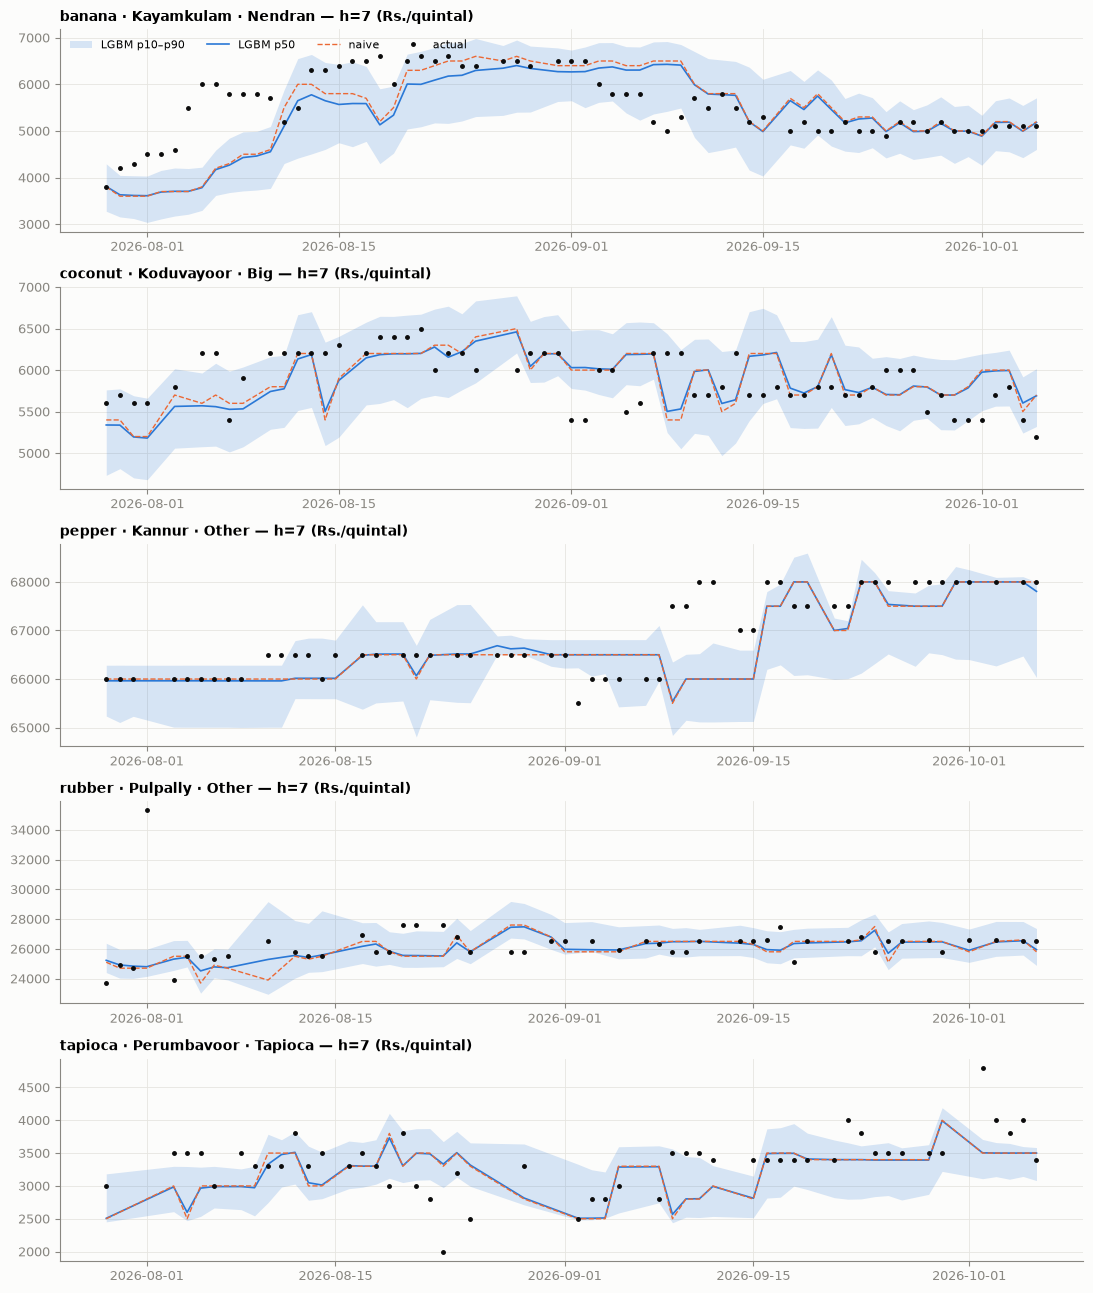

In [5]:
pick = {"banana": ("Kayamkulam", "Nendran"), "coconut": ("Koduvayoor", "Big"),
        "pepper": ("Kannur", "Other"), "rubber": ("Pulpally", "Other"),
        "tapioca": ("Perumbavoor", "Tapioca")}
fig, axes = plt.subplots(5, 1, figsize=(11, 13))
for ax, (crop, (market, variety)) in zip(axes, pick.items()):
    s = preds[(preds.commodity == crop) & (preds.market == market) & (preds.variety == variety)
              & (preds.horizon == 7)].copy()
    s["target_date"] = pd.to_datetime(s["target_date"])
    lg = s[s.model == "lgbm"].sort_values("target_date")
    nv = s[s.model == "naive"].sort_values("target_date")
    ax.fill_between(lg.target_date, lg.p10, lg.p90, color=MODEL_COLORS["lgbm"], alpha=0.18,
                    linewidth=0, label="LGBM p10–p90")
    ax.plot(lg.target_date, lg.pred, color=MODEL_COLORS["lgbm"], label="LGBM p50")
    ax.plot(nv.target_date, nv.pred, color=MODEL_COLORS["naive"], ls="--", lw=1, label="naive")
    ax.plot(lg.target_date, lg.actual, "o", color=INK, ms=2.5, label="actual")
    ax.set_title(f"{crop} · {market} · {variety} — h=7 (Rs./quintal)", loc="left")
axes[0].legend(fontsize=8, ncol=4, loc="upper left")
fig.tight_layout()

## 4. Feature importance (gain, latest fold's p50 model)

,gain_h1,gain_h7,gain_h14
feature,,,
market,62.4,60.6,21.5
roll_mean_7_rel,5.4,7.8,1.8
roll_cv_28,0.7,6.2,39.7
roll_mean_28_rel,1.0,4.5,10.8
log_last,0.5,2.6,5.1
spread,1.9,2.2,3.3
weekofyear,0.0,1.5,2.5
lag_28_rel,0.2,1.4,2.2
rain_30d,0.2,1.2,2.7


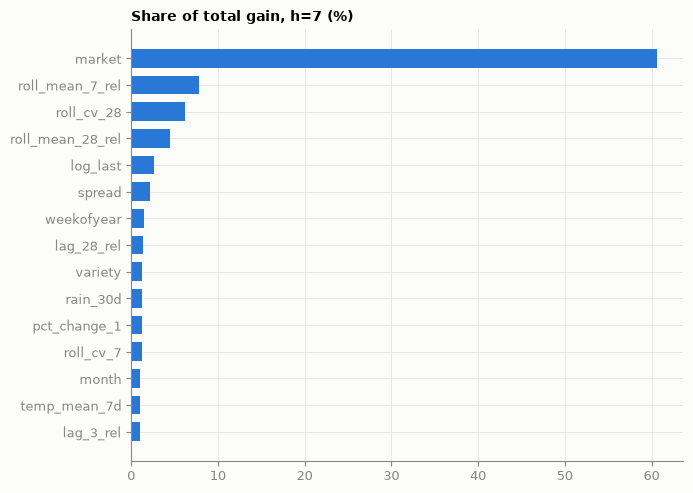

In [6]:
fi = pd.read_csv(report / "feature_importance.csv").set_index("feature")
share = (fi / fi.sum() * 100).round(1)
display(share.sort_values("gain_h7", ascending=False).head(15))
top = share["gain_h7"].sort_values().tail(15)
fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(top.index, top.to_numpy(), color=MODEL_COLORS["lgbm"], height=0.7)
ax.set_title("Share of total gain, h=7 (%)", loc="left")
fig.tight_layout()

## 5. Diagnostic: error by month over ~2 years (h=7, p50 only)

52 walk-forward folds × 14 days. Does the Onam season (Aug–Sep) break the model?

,n_lgbm,mape_lgbm,mape_naive,mase_lgbm,mase_naive
0,11043.0,5.28,5.281,2.67,2.633


,commodity,n_lgbm,mape_lgbm,mape_naive
0,banana,4962.0,7.75,7.72
1,coconut,1786.0,3.65,3.63
2,pepper,1685.0,1.22,1.15
3,rubber,491.0,3.57,3.65
4,tapioca,2119.0,4.51,4.63


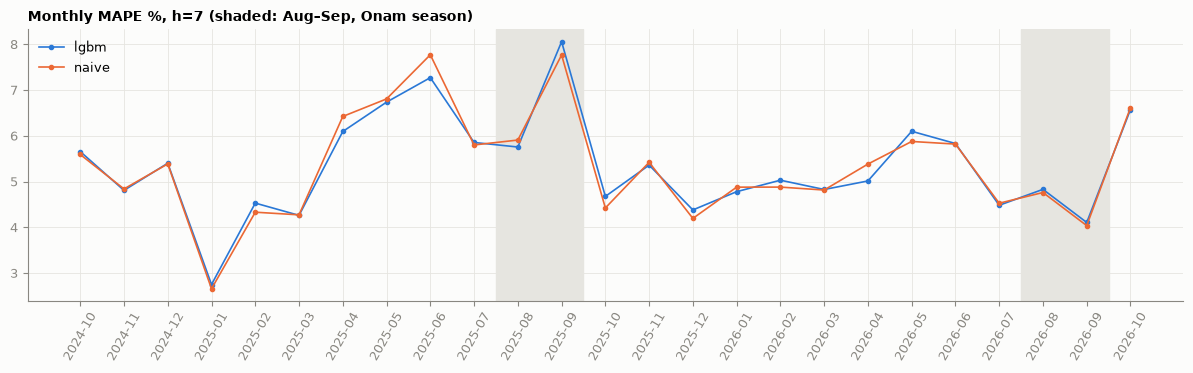

In [7]:
series = load_series()
f7 = build_features(prices, weather, last.date(), 7, series)
diag = run_backtest({7: f7}, prices, last.date(), n_folds=52, quantiles=(0.5,)).predictions
diag["month"] = pd.to_datetime(diag["target_date"]).dt.to_period("M").astype(str)
by_m = metrics_table(diag, ["month"])
piv = by_m.pivot(index="month", columns="model", values="mape")[["lgbm", "naive"]]
fig, ax = plt.subplots(figsize=(12, 3.8))
for m in ("lgbm", "naive"):
    ax.plot(piv.index, piv[m], marker="o", ms=3, color=MODEL_COLORS[m], label=m)
for i, mth in enumerate(piv.index):
    if mth[-2:] in ("08", "09"):
        ax.axvspan(i - 0.5, i + 0.5, color=GRID, zorder=0)
ax.set_title("Monthly MAPE %, h=7 (shaded: Aug–Sep, Onam season)", loc="left")
ax.tick_params(axis="x", rotation=60)
ax.legend()
fig.tight_layout()
diag_c = comparison_table(diag, ["commodity"])
diag_all = comparison_table(diag, ["horizon"])
display(diag_all[["n_lgbm", "mape_lgbm", "mape_naive", "mase_lgbm", "mase_naive"]].round(3))
diag_c[["commodity", "n_lgbm", "mape_lgbm", "mape_naive"]].round(2)

In [8]:
diag["onam_season"] = pd.to_datetime(diag["target_date"]).dt.month.isin([8, 9])
comparison_table(diag, ["commodity", "onam_season"])[
    ["commodity", "onam_season", "n_lgbm", "mape_lgbm", "mape_naive"]].round(2)

,commodity,onam_season,n_lgbm,mape_lgbm,mape_naive
0,banana,False,4167.0,7.66,7.68
1,banana,True,795.0,8.18,7.91
2,coconut,False,1491.0,3.60,3.57
3,coconut,True,295.0,3.95,3.94
4,pepper,False,1413.0,1.26,1.18
5,pepper,True,272.0,0.99,0.97
6,rubber,False,413.0,3.63,3.62
7,rubber,True,78.0,3.25,3.82
8,tapioca,False,1773.0,4.26,4.37
9,tapioca,True,346.0,5.79,5.97


## 6. Diagnostic: before vs after the Agmarknet 2.0 portal switch

In [9]:
switch = pd.Timestamp(settings.portal_switch_date)
diag["period"] = np.where(pd.to_datetime(diag["origin_date"]) >= switch, "post-switch", "pre-switch")
comparison_table(diag, ["period"])[["period", "n_lgbm", "mape_lgbm", "mape_naive", "mase_lgbm",
                                    "mase_naive"]].round(3)

,period,n_lgbm,mape_lgbm,mape_naive,mase_lgbm,mase_naive
0,post-switch,4846.0,4.975,4.956,2.571,2.553
1,pre-switch,6197.0,5.518,5.536,2.750,2.696


In [10]:
comparison_table(diag, ["commodity", "period"])[
    ["commodity", "period", "n_lgbm", "mape_lgbm", "mape_naive"]].round(2)

,commodity,period,n_lgbm,mape_lgbm,mape_naive
0,banana,post-switch,2180.0,7.17,7.15
1,banana,pre-switch,2782.0,8.20,8.17
2,coconut,post-switch,796.0,4.15,4.06
3,coconut,pre-switch,990.0,3.26,3.28
4,pepper,post-switch,745.0,0.71,0.70
5,pepper,pre-switch,940.0,1.62,1.50
6,rubber,post-switch,240.0,3.04,3.06
7,rubber,pre-switch,251.0,4.08,4.21
8,tapioca,post-switch,885.0,4.44,4.45
9,tapioca,pre-switch,1234.0,4.56,4.76


## 7. Conclusions

*Numbers from the 2026-10-07 run on Neon data (prices to 2026-10-06), DagsHub parent run `08290bba`.*

**Headline — LightGBM does not beat the naive forecast.** Pooled over 19 series:

| h | LGBM MAPE | naive | seasonal-naive | 7-d MA | LGBM MASE | naive MASE | p10–p90 coverage |
|---|---|---|---|---|---|---|---|
| 1 | 2.59 | 2.58 | 4.67 | 3.21 | 1.15 | 1.16 | 82.7 % |
| 7 | 4.77 | 4.71 | 4.71 | 5.16 | 2.18 | 2.15 | 80.1 % |
| 14 | 7.08 | 6.97 | 6.97 | 7.38 | 3.42 | 3.21 | 76.8 % |

* The p50 forecast tracks the last price (section 3); the p50 models early-stop at ~50 trees —
  the learnable signal beyond "no change" is tiny. The ≈2-year diagnostic confirms it is not a
  window artefact: 5.28 vs 5.28 % at h=7 over 11k forecasts, in every quarter and pre/post switch.
* **Where LGBM wins:** rubber · Pulpally (all horizons, e.g. h=7 2.95 vs 3.24), tapioca ·
  Perumbavoor (12.2 vs 12.4), banana Elamad / Chenkal at h=14. **Where it loses most:**
  flat series (pepper and tapioca at North Paravur: naive MAPE 0.00 — any predicted move is
  error) and coconut at h=14 (6.1 vs 5.3).
* **Onam season breaks banana** (diagnostic): Aug–Sep MAPE 8.18 vs naive 7.91 — the festival
  flags are on the target date but 2–8 years of history give too few Onam cycles per series.
* **Portal switch:** errors are *lower* after 2025-11-07 for both models (h=7 ≈ 4.98 vs 5.52 %),
  i.e. the clean layer handles the cut-over; it is not a source of model error.
* **Uncertainty is the useful output today:** p10–p90 coverage is 80–83 % at h=1/7 (target 80 %),
  under-covering at h=14 (77 %) and for volatile VFPCK banana series (47–66 %).
* `market` carries ~60 % of the gain — the model mostly learns per-series drift.

**Recommendations for Phase 3+:** promote nothing that loses to naive (the gate in CLAUDE.md will
correctly keep naive-equivalent behaviour); add **arrival volumes** (Agmarknet publishes them; the
strongest known price driver, not stored in Phase 1) and leading-market signals; consider
forecasting only series with real movement, and serve the p10–p90 band prominently.